# 6.3 Structural flexibility â€” Figure 2 and Supplementary Figure S1
This notebook derives all matrices from the fitted model curves, evaluates them at 5 km, and draws the same-period and normalized cross-period comparisons.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts/models").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from threadpoolctl import threadpool_limits
from scripts.common import core
MODEL_DIR = ROOT / "results/analysis/model_fit"
FIGURES = ROOT / "results/figures"
FIGURES.mkdir(parents=True, exist_ok=True)
payload = core.load_pickle_cross_platform(MODEL_DIR / "models.pkl")

In [2]:
from scripts.common import plotting as p
from scripts.analysis.structural_flexibility.figures import move_panel_labels
periods, curves = p.load_semivariogram_curves(MODEL_DIR / "models.pkl")
h = 5.0
matrices = p.build_fixed_distance_matrices(curves, (h,))
normalized = p.build_normalized_decay_matrices(curves, (h,))
# Display the actual normalized correlation matrices used in Figure 2.
for method, by_distance in normalized.items():
    print(method)
    display(pd.DataFrame(by_distance[h], index=periods, columns=periods))

Pairwise empirical semivariogram


,0.01,0.03,0.06,0.10,0.30,0.60,1.00,3.00,6.00
0.01,0.520683,0.523448,0.526815,0.524919,0.493890,0.549834,0.608052,0.558952,0.562469
0.03,0.523448,0.524194,0.527409,0.526604,0.495227,0.548308,0.610220,0.566457,0.584424
0.06,0.526815,0.527409,0.514358,0.522018,0.494626,0.535107,0.607087,0.552852,0.570194
0.10,0.524919,0.526604,0.522018,0.498575,0.503034,0.550561,0.603640,0.532998,0.599962
0.30,0.493890,0.495227,0.494626,0.503034,0.443030,0.539101,0.590268,0.453096,0.410634
0.60,0.549834,0.548308,0.535107,0.550561,0.539101,0.517893,0.576198,0.556853,0.505532
1.00,0.608052,0.610220,0.607087,0.603640,0.590268,0.576198,0.545164,0.621877,0.587058
3.00,0.558952,0.566457,0.552852,0.532998,0.453096,0.556853,0.621877,0.626715,0.634101
6.00,0.562469,0.584424,0.570194,0.599962,0.410634,0.505532,0.587058,0.634101,0.660310


GH08 semivariogram


,0.01,0.03,0.06,0.10,0.30,0.60,1.00,3.00,6.00
0.01,0.520682,0.524194,0.514358,0.498575,0.443030,0.517893,0.545164,0.626715,0.66031
0.03,0.524194,0.524194,0.514358,0.498575,0.443030,0.517893,0.545164,0.626715,0.66031
0.06,0.514358,0.514358,0.514358,0.498575,0.443030,0.517893,0.545164,0.626715,0.66031
0.10,0.498575,0.498575,0.498575,0.498575,0.443030,0.517893,0.545164,0.626715,0.66031
0.30,0.443030,0.443030,0.443030,0.443030,0.443030,0.517893,0.545164,0.626715,0.66031
0.60,0.517893,0.517893,0.517893,0.517893,0.517893,0.517893,0.545164,0.626715,0.66031
1.00,0.545164,0.545164,0.545164,0.545164,0.545164,0.545164,0.545164,0.626715,0.66031
3.00,0.626715,0.626715,0.626715,0.626715,0.626715,0.626715,0.626715,0.626715,0.66031
6.00,0.660310,0.660310,0.660310,0.660310,0.660310,0.660310,0.660310,0.660310,0.66031


PCA semivariogram


,0.01,0.03,0.06,0.10,0.30,0.60,1.00,3.00,6.00
0.01,0.586906,0.588803,0.592495,0.599769,0.591606,0.585086,0.579918,0.577867,0.579035
0.03,0.588803,0.587337,0.592418,0.601198,0.592435,0.582636,0.576029,0.577903,0.582708
0.06,0.592495,0.592418,0.590876,0.602674,0.594511,0.570129,0.554735,0.574411,0.596853
0.10,0.599769,0.601198,0.602674,0.584575,0.589579,0.561626,0.537797,0.567416,0.601104
0.30,0.591606,0.592435,0.594511,0.589579,0.570904,0.608658,0.603821,0.565216,0.532471
0.60,0.585086,0.582636,0.570129,0.561626,0.608658,0.589525,0.630247,0.586340,0.540666
1.00,0.579918,0.576029,0.554735,0.537797,0.603821,0.630247,0.595091,0.604231,0.572495
3.00,0.577867,0.577903,0.574411,0.567416,0.565216,0.586340,0.604231,0.592860,0.639990
6.00,0.579035,0.582708,0.596853,0.601104,0.532471,0.540666,0.572495,0.639990,0.613420


Kronecker semivariogram


,0.01,0.03,0.06,0.10,0.30,0.60,1.00,3.00,6.00
0.01,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028
0.03,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028
0.06,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028
0.10,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028
0.30,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028
0.60,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028
1.00,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028
3.00,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028
6.00,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028,0.534028


LMC semivariogram


,0.01,0.03,0.06,0.10,0.30,0.60,1.00,3.00,6.00
0.01,0.643451,0.645034,0.646528,0.642969,0.614929,0.649344,0.688401,0.583872,0.549602
0.03,0.645034,0.645207,0.647177,0.644248,0.615469,0.648363,0.688645,0.587628,0.578055
0.06,0.646528,0.647177,0.642537,0.640827,0.617870,0.645063,0.687582,0.556568,0.567729
0.10,0.642969,0.644248,0.640827,0.624511,0.619563,0.654554,0.694455,0.511464,0.551831
0.30,0.614929,0.615469,0.617870,0.619563,0.568318,0.629154,0.677469,0.517283,0.330178
0.60,0.649344,0.648363,0.645063,0.654554,0.629154,0.620776,0.655989,0.625105,0.535717
1.00,0.688401,0.688645,0.687582,0.694455,0.677469,0.655989,0.633277,0.669460,0.620008
3.00,0.583872,0.587628,0.556568,0.511464,0.517283,0.625105,0.669460,0.679461,0.698903
6.00,0.549602,0.578055,0.567729,0.551831,0.330178,0.535717,0.620008,0.698903,0.732274


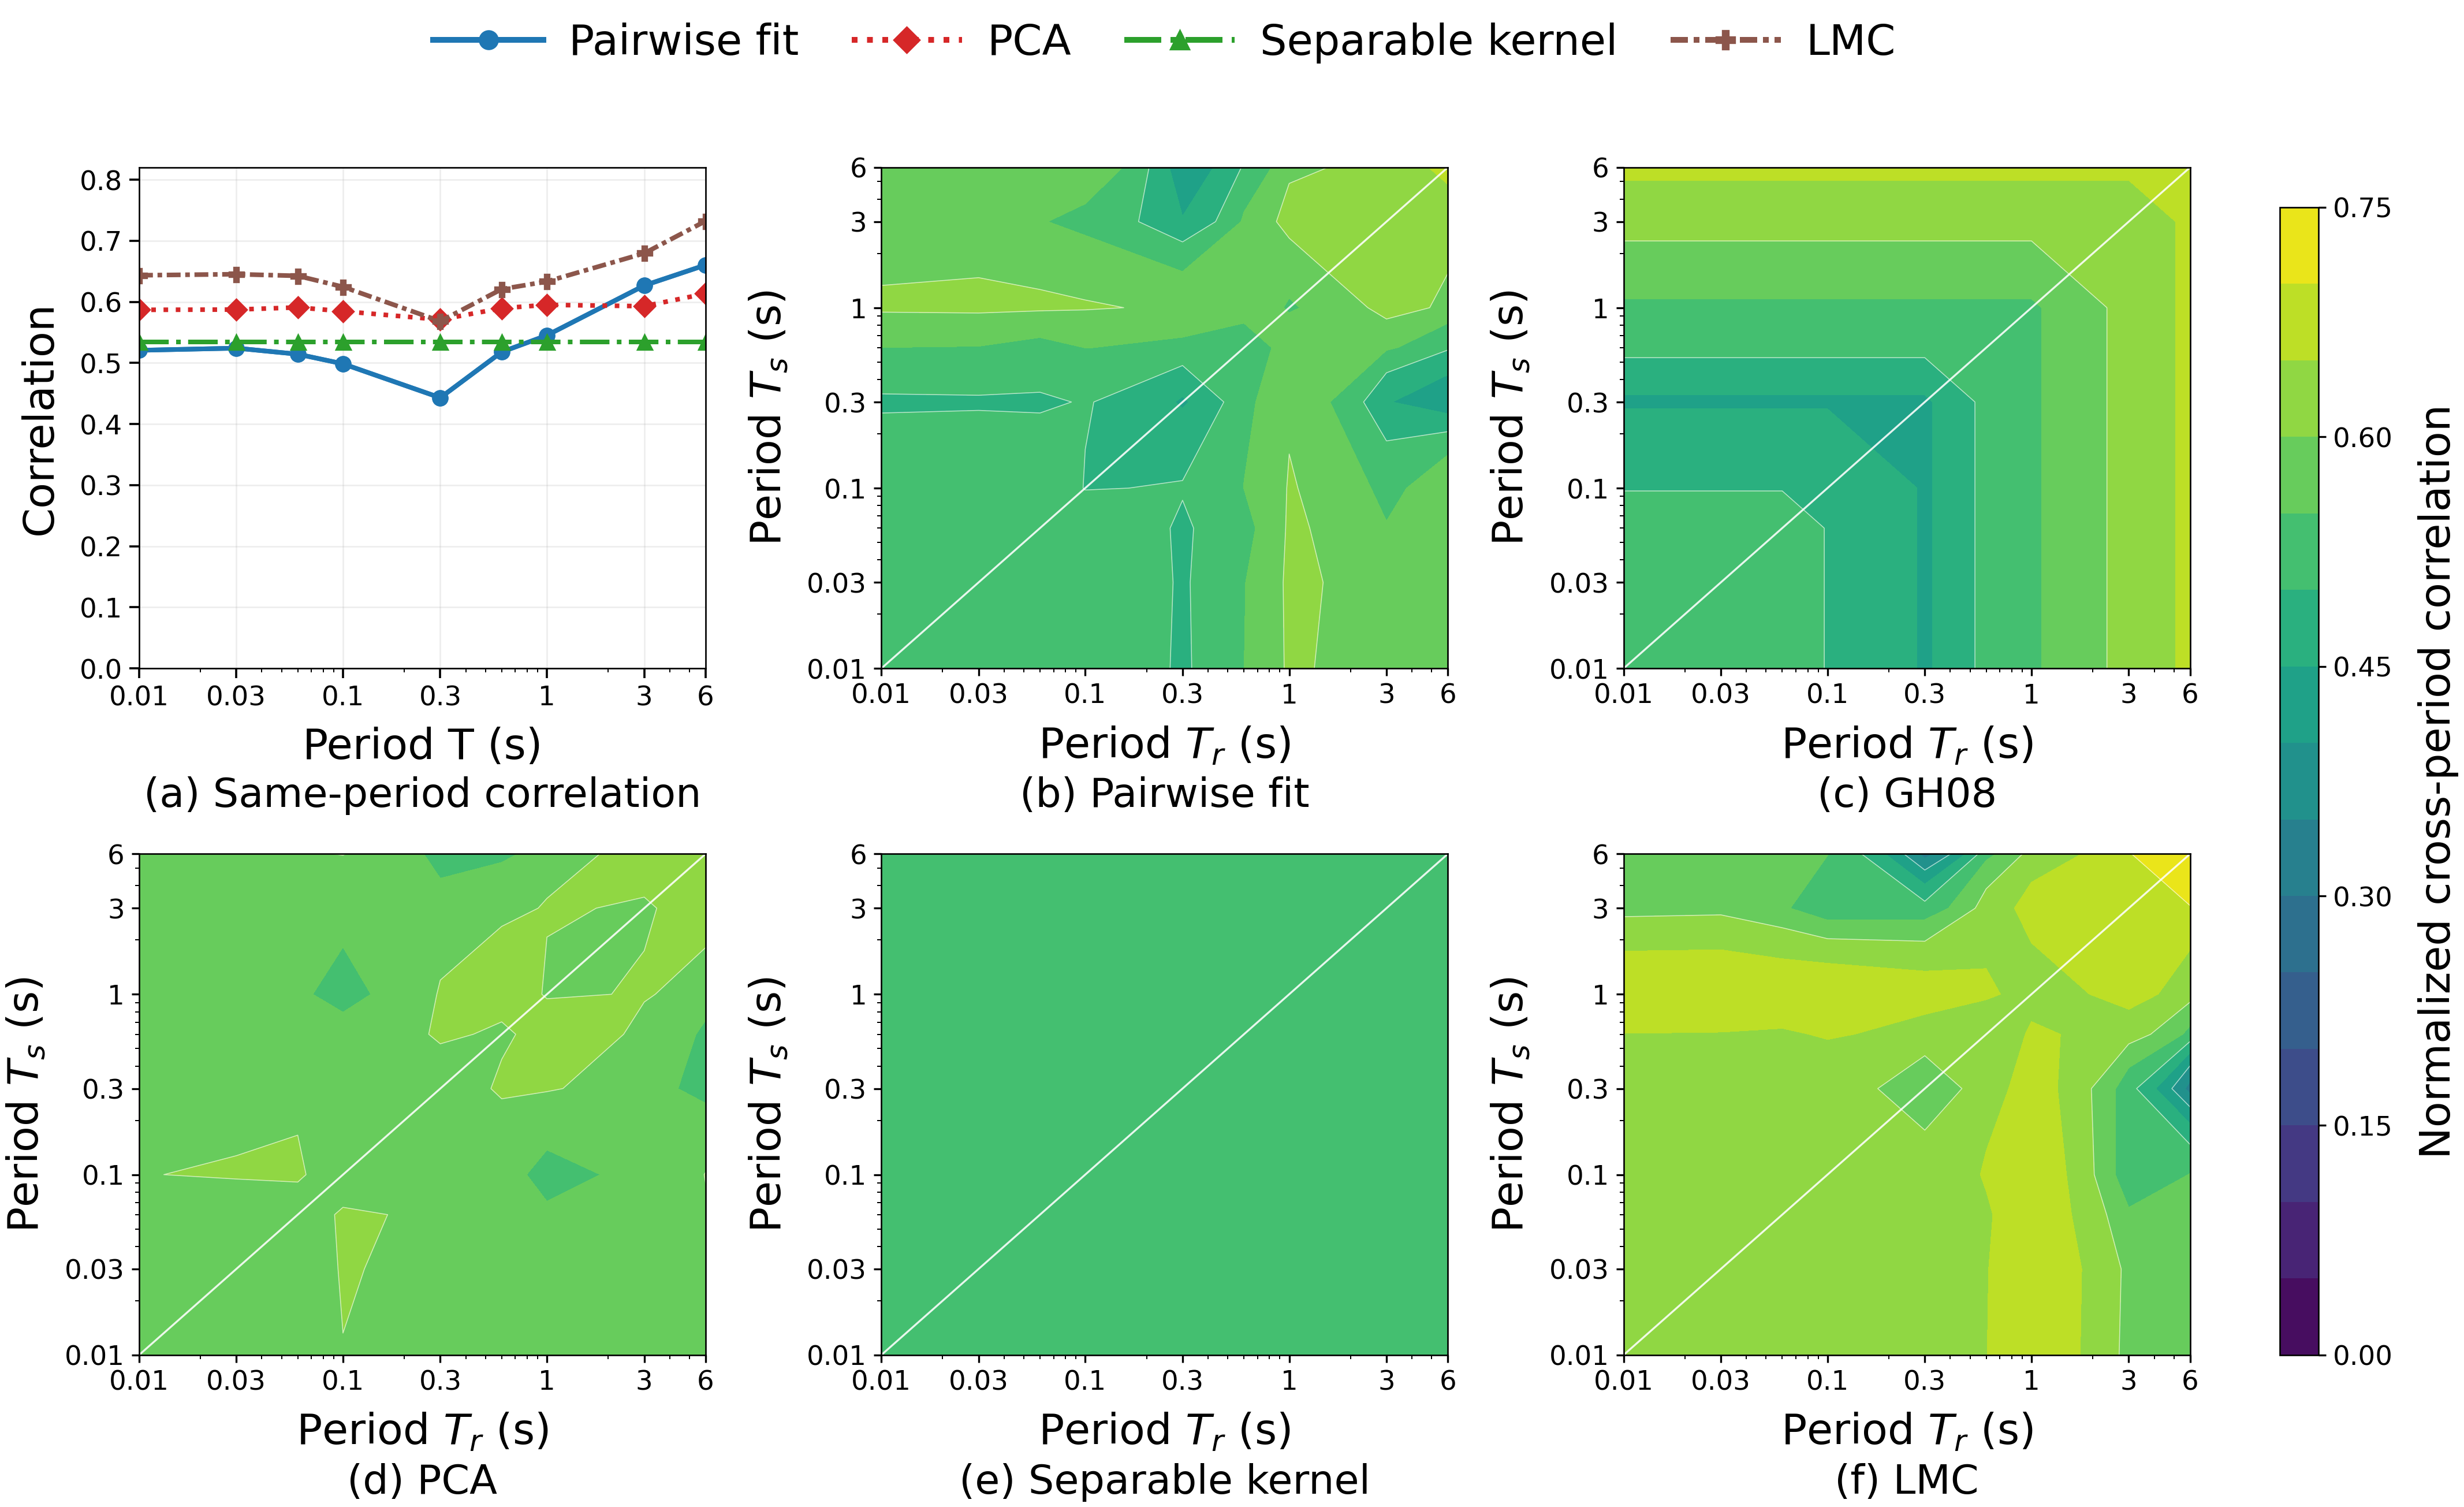

In [3]:
levels = np.linspace(*p._comparison_limits(normalized, h), 16)
fig = p.plot_combined_distance_figure(periods, matrices, normalized, h, levels)
move_panel_labels(fig, 6)
fig.savefig(FIGURES / "fig02_cross_period_flexibility.png", dpi=240, bbox_inches="tight", pad_inches=.04)
display(Image(filename=str(FIGURES / "fig02_cross_period_flexibility.png")))
plt.close(fig)

## Supplementary Figure S1
The additional models use the same normalization: correlation at 5 km divided elementwise by the colocated correlation.

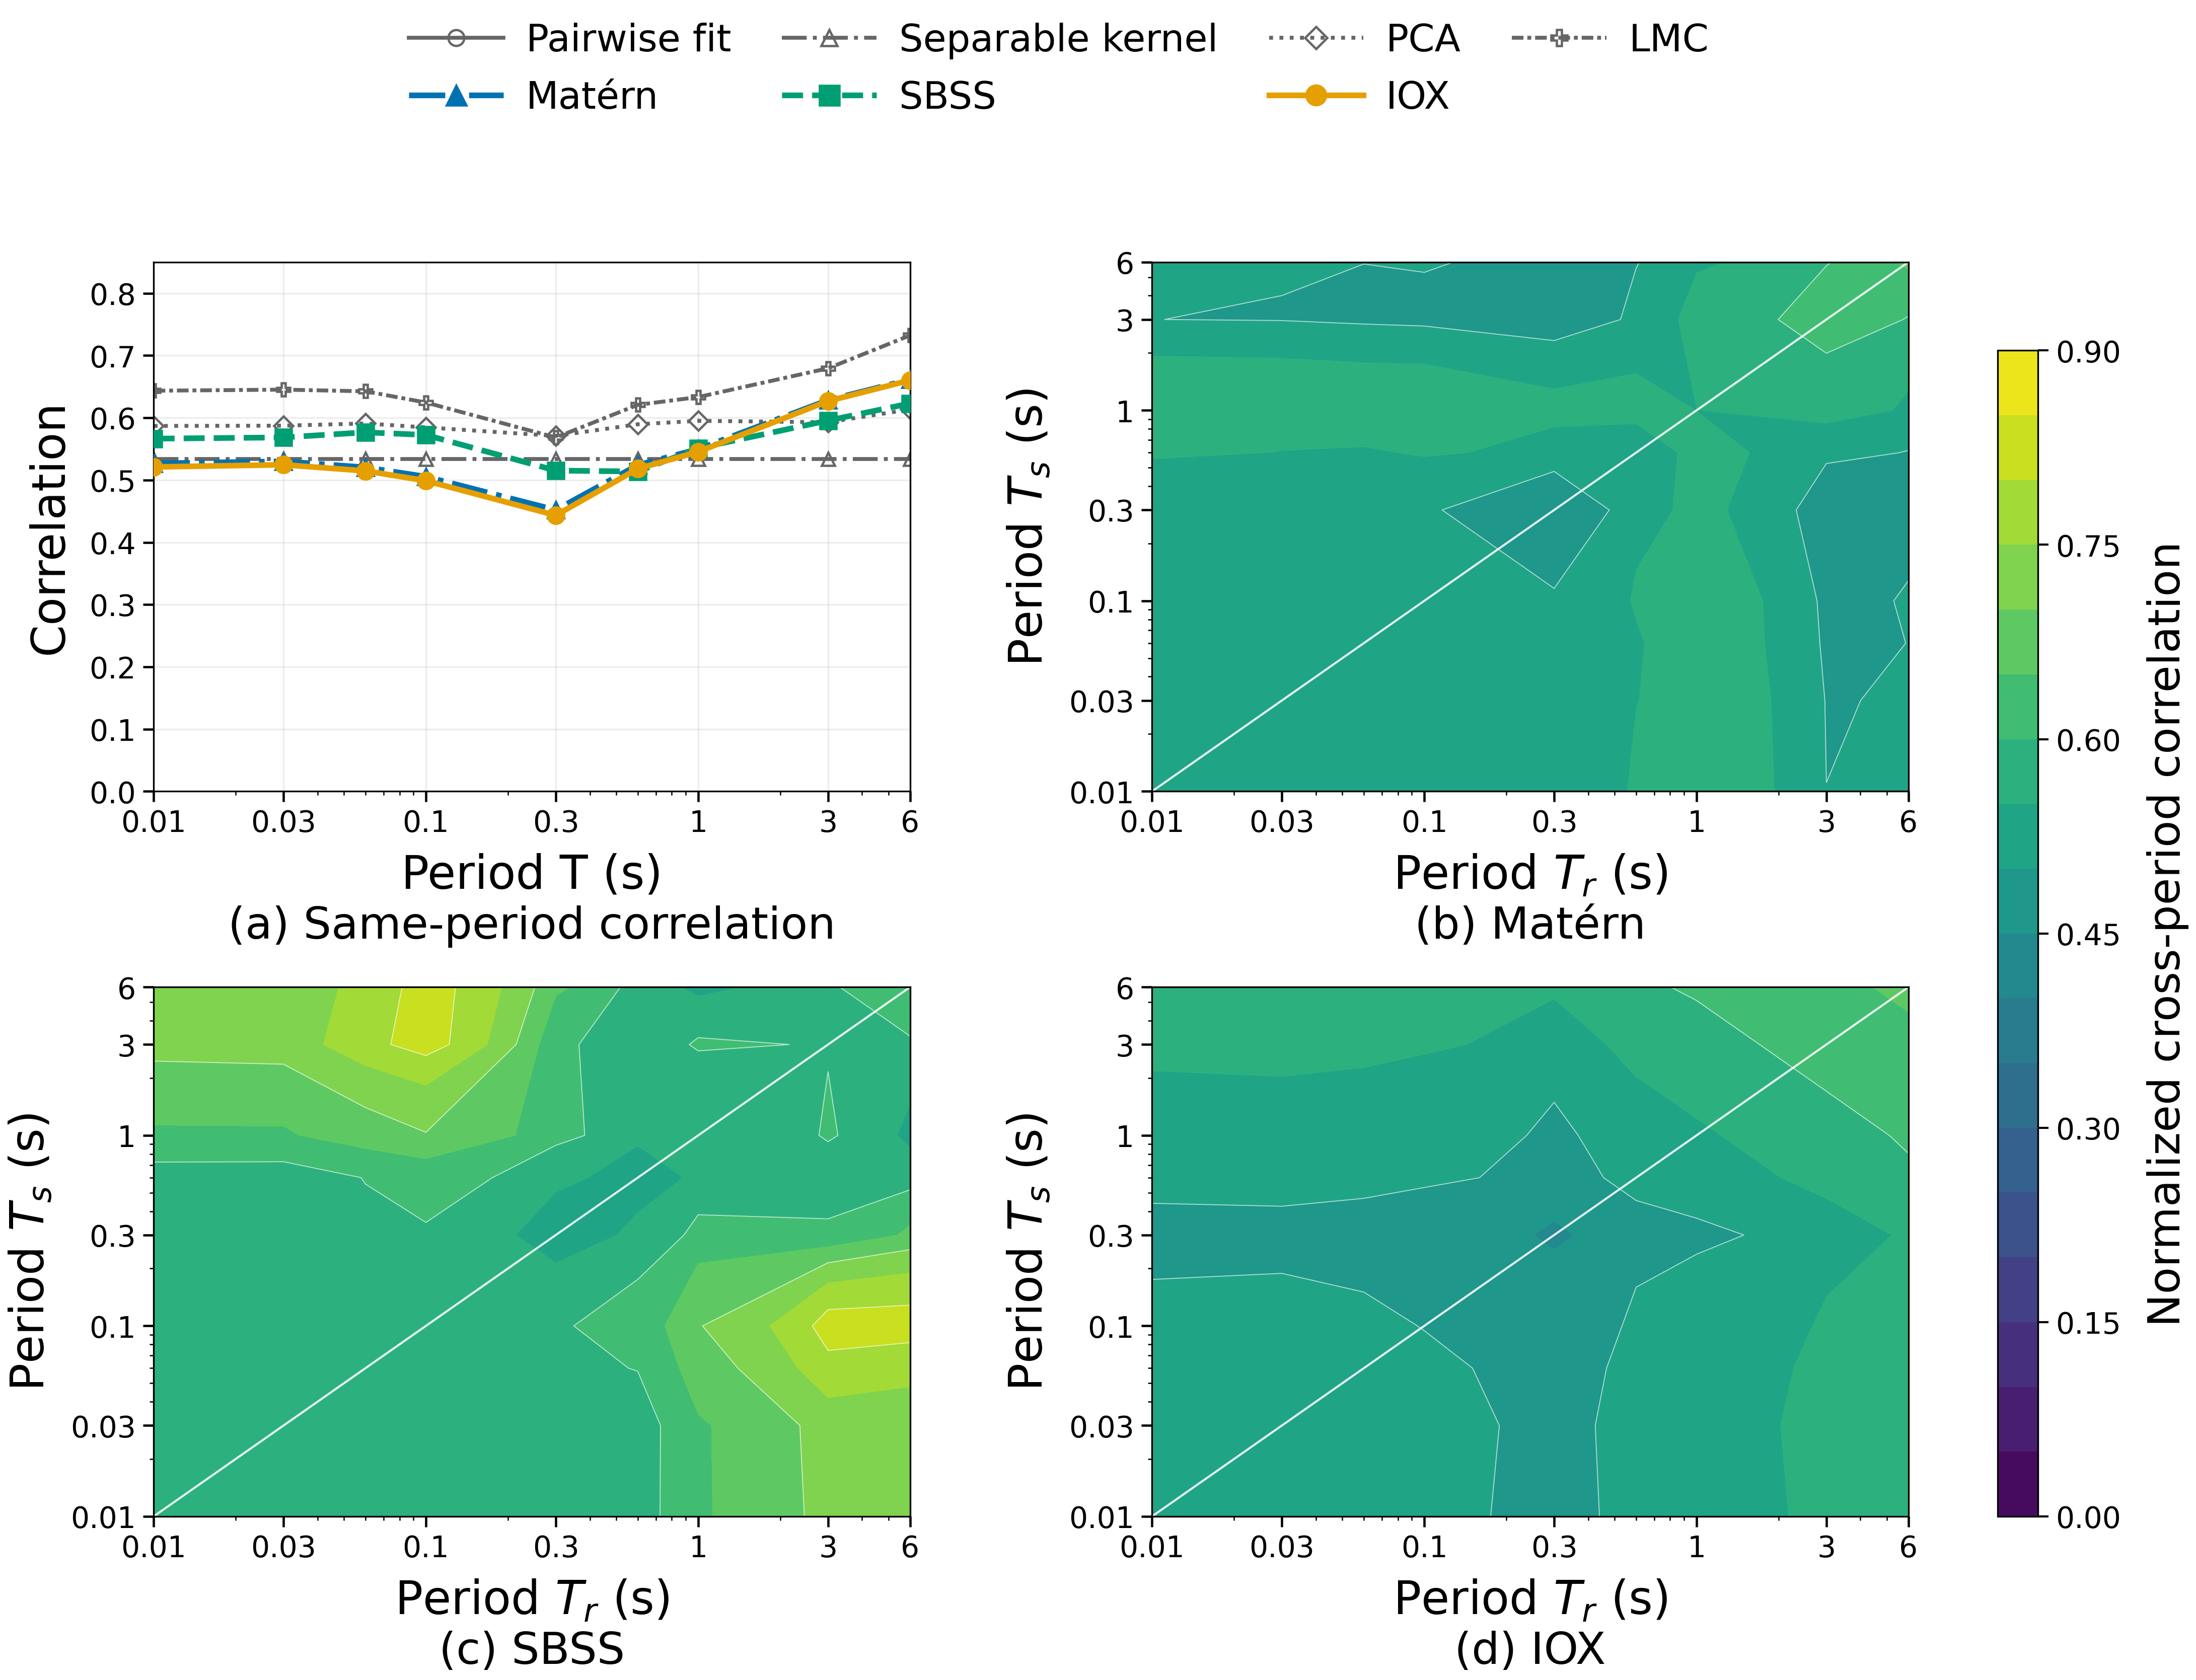

In [4]:
extra = {}
for method in (*p.BASE_METHODS, *p.NEW_METHODS):
    grid, rho = payload["cross_period_psd"]["curves"][method]
    rho0 = p.interpolate_correlation_matrix(np.asarray(grid), np.asarray(rho), 0.)
    rho5 = p.interpolate_correlation_matrix(np.asarray(grid), np.asarray(rho), h)
    extra[method] = {"rho_0": rho0, "rho_h": rho5, "rhobar": rho5 / rho0}
fig, _, _ = p.plot_comparison(ROOT, periods, extra)
move_panel_labels(fig, 4)
fig.savefig(FIGURES / "figS01_additional_models.png", dpi=300, bbox_inches="tight", pad_inches=.05)
display(Image(filename=str(FIGURES / "figS01_additional_models.png")))
plt.close(fig)